# Benchmark Performance Analysis
Visualization of foveation impact on system performance across 4 configurations:
- **baseline_off**: No foveation
- **fov_cfg1**: Foveal 0.15, Peripheral 0.35, Transition 0.5, Outer 0.125
- **fov_cfg2**: Foveal 0.20, Peripheral 0.40, Transition 0.6, Outer 0.20
- **fov_cfg3**: Foveal 0.10, Peripheral 0.30, Transition 0.4, Outer 0.08

Each experiment has 5 runs, averaged for statistical reliability.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import glob
import re

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Load and Parse CSV Files from Each Folder

In [142]:
# Define benchmark folder structure
benchmark_root = Path("benchmarks")
experiments = {
    "baseline_off": "Baseline (No Foveation)",
    "fov_cfg1": "Fov Config 1 (fr=0.20, pr=0.40)",
    "fov_cfg2": "Fov Config 2 (fr=0.15, pr=0.35)",
    "fov_cfg3": "Fov Config 3 (fr=0.10, pr=0.30)",
}

# Load all CSVs from each experiment folder
experiment_data = {}

for folder_name, display_name in experiments.items():
    folder_path = benchmark_root / folder_name
    csv_files = sorted(glob.glob(str(folder_path / "*.csv")))
    
    # Filter only .csv files (exclude .log files)
    csv_files = [f for f in csv_files if not "_viewer.log" in f]
    
    print(f"\n{display_name}:")
    print(f"  Folder: {folder_path}")
    print(f"  Found {len(csv_files)} CSV files")
    
    # Load each CSV
    dfs = []
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            dfs.append(df)
            print(f"    Loaded: {Path(csv_file).name} ({len(df)} rows)")
        except Exception as e:
            print(f"    ERROR loading {csv_file}: {e}")
    
    if dfs:
        experiment_data[folder_name] = {
            "display_name": display_name,
            "csv_files": csv_files,
            "dataframes": dfs
        }

print(f"\nSuccessfully loaded {len(experiment_data)} experiment configurations")


Baseline (No Foveation):
  Folder: benchmarks/baseline_off
  Found 5 CSV files
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-off_20260430_003013.csv (41 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-off_20260430_003116.csv (40 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-off_20260430_003218.csv (40 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-off_20260430_003320.csv (40 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-off_20260430_003422.csv (40 rows)

Fov Config 1 (fr=0.20, pr=0.40):
  Folder: benchmarks/fov_cfg1
  Found 5 CSV files
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-on_fr0p20_pr0p40_tk0p6_ok0p20_20260430_004038.csv (40 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-on_fr0p20_pr0p40_tk0p6_ok0p20_20260430_004140.csv (40 rows)
    Loaded: monitor_rt60s_i1s_api-opengl_cam-flight_asz1_fov-on_fr0p20_pr0p40_tk0p6_ok0p20_20260430_004242.csv (41 rows

## Calculate Average Metrics Across 5 CSV Files Per Experiment

In [143]:
# Calculate averaged metrics for each experiment
averaged_data = {}

for exp_name, exp_info in experiment_data.items():
    dfs = exp_info["dataframes"]
    
    # Combine all dataframes for this experiment
    combined = pd.concat(dfs, ignore_index=True)
    
    # Calculate mean for each column
    mean_metrics = combined.mean(numeric_only=True)
    
    # Also keep time-series by averaging across runs at each elapsed_s value
    time_series = combined.groupby('elapsed_s').mean(numeric_only=True).reset_index()
    
    averaged_data[exp_name] = {
        "mean_metrics": mean_metrics,
        "time_series": time_series,
        "combined": combined,
        "display_name": exp_info["display_name"]
    }
    
    print(f"\n{exp_info['display_name']} - Summary Statistics:")
    print(f"  Avg CPU Usage (user+sys): {mean_metrics['cpu_usr_pct'] + mean_metrics['cpu_sys_pct']:.2f}%")
    print(f"  Avg GPU Usage: {mean_metrics['gpu_util_pct']:.2f}%")
    print(f"  Avg CPU Power: {mean_metrics['cpu_power_w']:.2f}W")
    print(f"  Avg GPU Power: {mean_metrics['gpu_power_w']:.2f}W")
    print(f"  Total Avg Power: {mean_metrics['cpu_power_w'] + mean_metrics['gpu_power_w']:.2f}W")
    print(f"  Avg CPU Temp: {mean_metrics['cpu_temp_c']:.2f}°C")
    print(f"  Avg GPU Temp: {mean_metrics['gpu_temp_c']:.2f}°C")
    print(f"  Avg Memory Used: {mean_metrics['mem_used_mb']:.0f}MB")
    print(f"  Avg GPU Memory Used: {mean_metrics['gpu_mem_used_mb']:.0f}MB")


Baseline (No Foveation) - Summary Statistics:
  Avg CPU Usage (user+sys): 18.60%
  Avg GPU Usage: 0.00%
  Avg CPU Power: 65.47W
  Avg GPU Power: 27.84W
  Total Avg Power: 93.31W
  Avg CPU Temp: 59.65°C
  Avg GPU Temp: 55.00°C
  Avg Memory Used: 8099MB
  Avg GPU Memory Used: 371MB

Fov Config 1 (fr=0.20, pr=0.40) - Summary Statistics:
  Avg CPU Usage (user+sys): 18.24%
  Avg GPU Usage: 0.00%
  Avg CPU Power: 65.14W
  Avg GPU Power: 27.68W
  Total Avg Power: 92.82W
  Avg CPU Temp: 60.29°C
  Avg GPU Temp: 54.00°C
  Avg Memory Used: 8074MB
  Avg GPU Memory Used: 371MB

Fov Config 2 (fr=0.15, pr=0.35) - Summary Statistics:
  Avg CPU Usage (user+sys): 17.89%
  Avg GPU Usage: 0.00%
  Avg CPU Power: 66.07W
  Avg GPU Power: 27.78W
  Total Avg Power: 93.85W
  Avg CPU Temp: 60.72°C
  Avg GPU Temp: 54.45°C
  Avg Memory Used: 8100MB
  Avg GPU Memory Used: 371MB

Fov Config 3 (fr=0.10, pr=0.30) - Summary Statistics:
  Avg CPU Usage (user+sys): 17.50%
  Avg GPU Usage: 0.00%
  Avg CPU Power: 64.25W
 

## Visualization 1: CPU & GPU Utilization Over Time

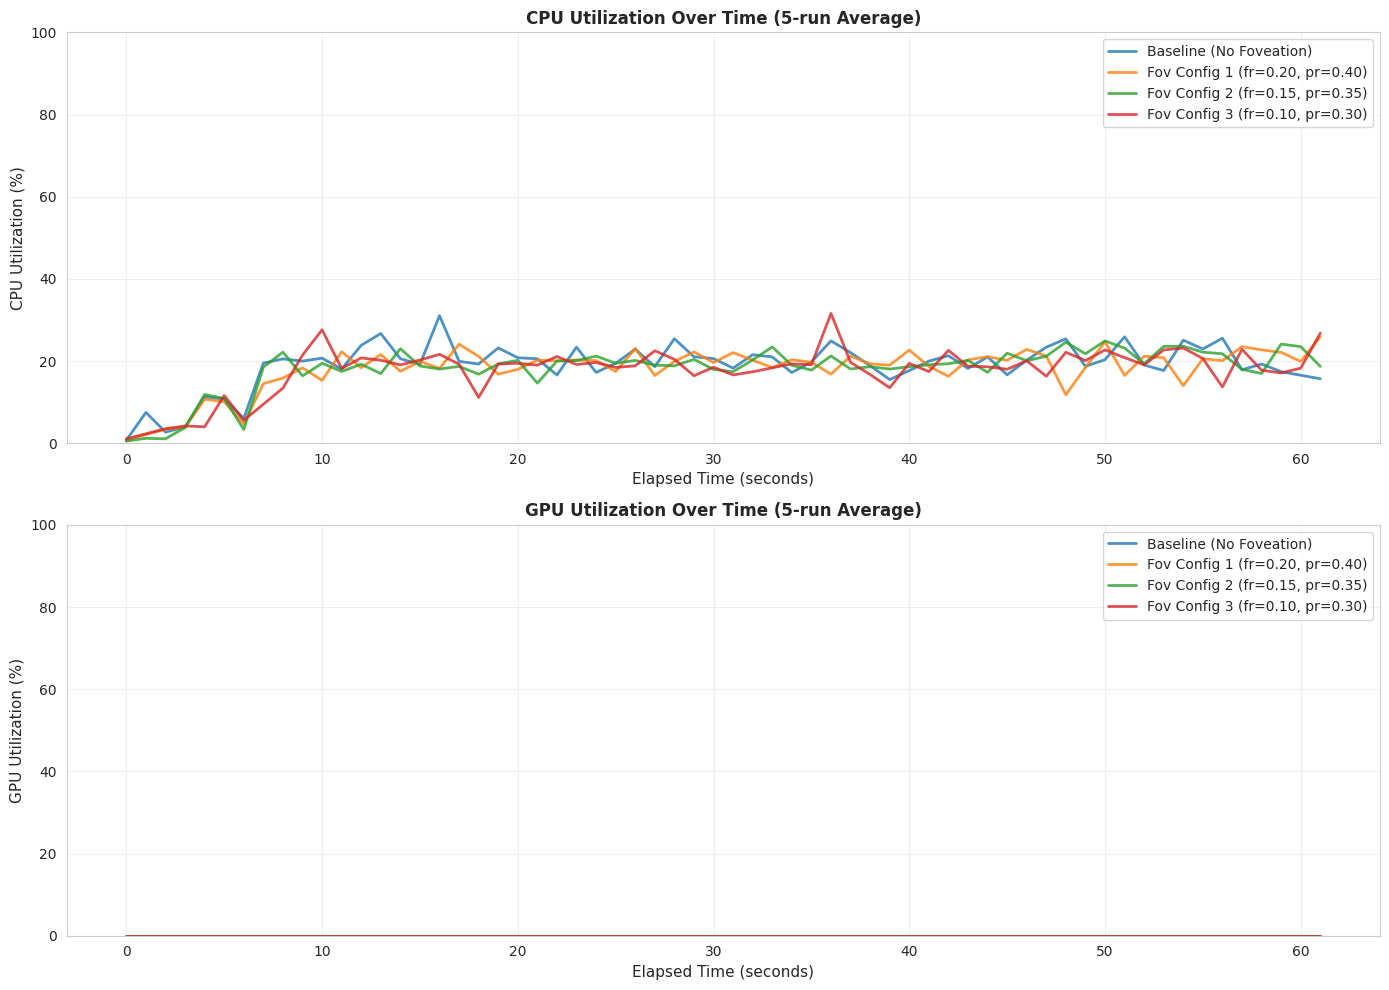

In [144]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# CPU Utilization Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    cpu_total = ts['cpu_usr_pct'] + ts['cpu_sys_pct']
    ax1.plot(ts['elapsed_s'], cpu_total, label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax1.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax1.set_ylabel('CPU Utilization (%)', fontsize=11)
ax1.set_title('CPU Utilization Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# GPU Utilization Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax2.plot(ts['elapsed_s'], ts['gpu_util_pct'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax2.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax2.set_ylabel('GPU Utilization (%)', fontsize=11)
ax2.set_title('GPU Utilization Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Visualization 2: Power Consumption Over Time

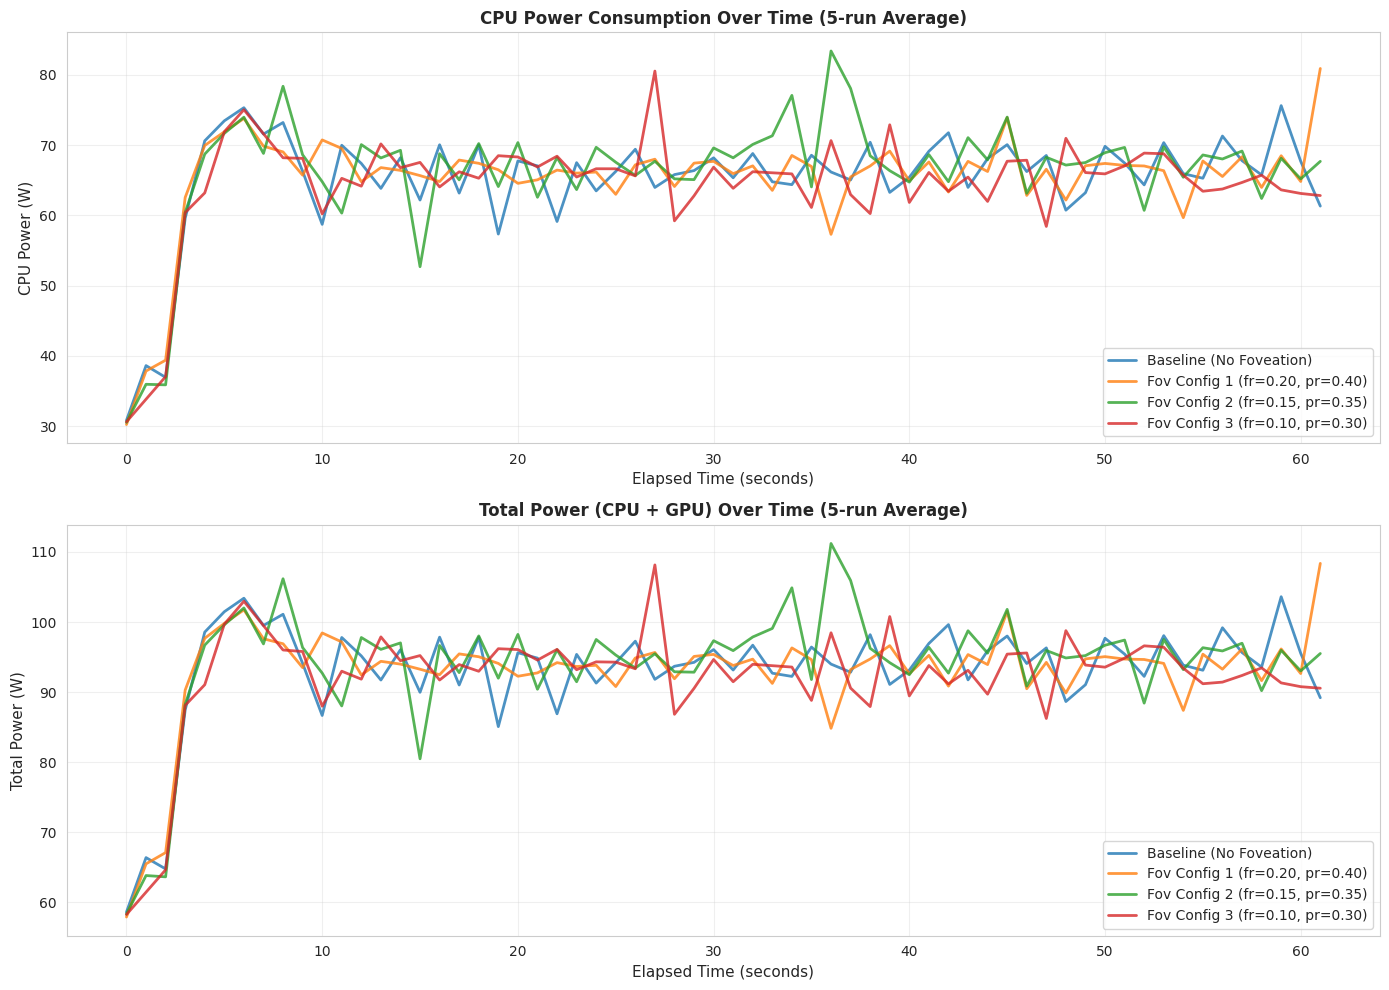

In [145]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# CPU Power Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax1.plot(ts['elapsed_s'], ts['cpu_power_w'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax1.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax1.set_ylabel('CPU Power (W)', fontsize=11)
ax1.set_title('CPU Power Consumption Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Total Power (CPU + GPU) Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    total_power = ts['cpu_power_w'] + ts['gpu_power_w']
    ax2.plot(ts['elapsed_s'], total_power, label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax2.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax2.set_ylabel('Total Power (W)', fontsize=11)
ax2.set_title('Total Power (CPU + GPU) Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 3: Temperature Trends

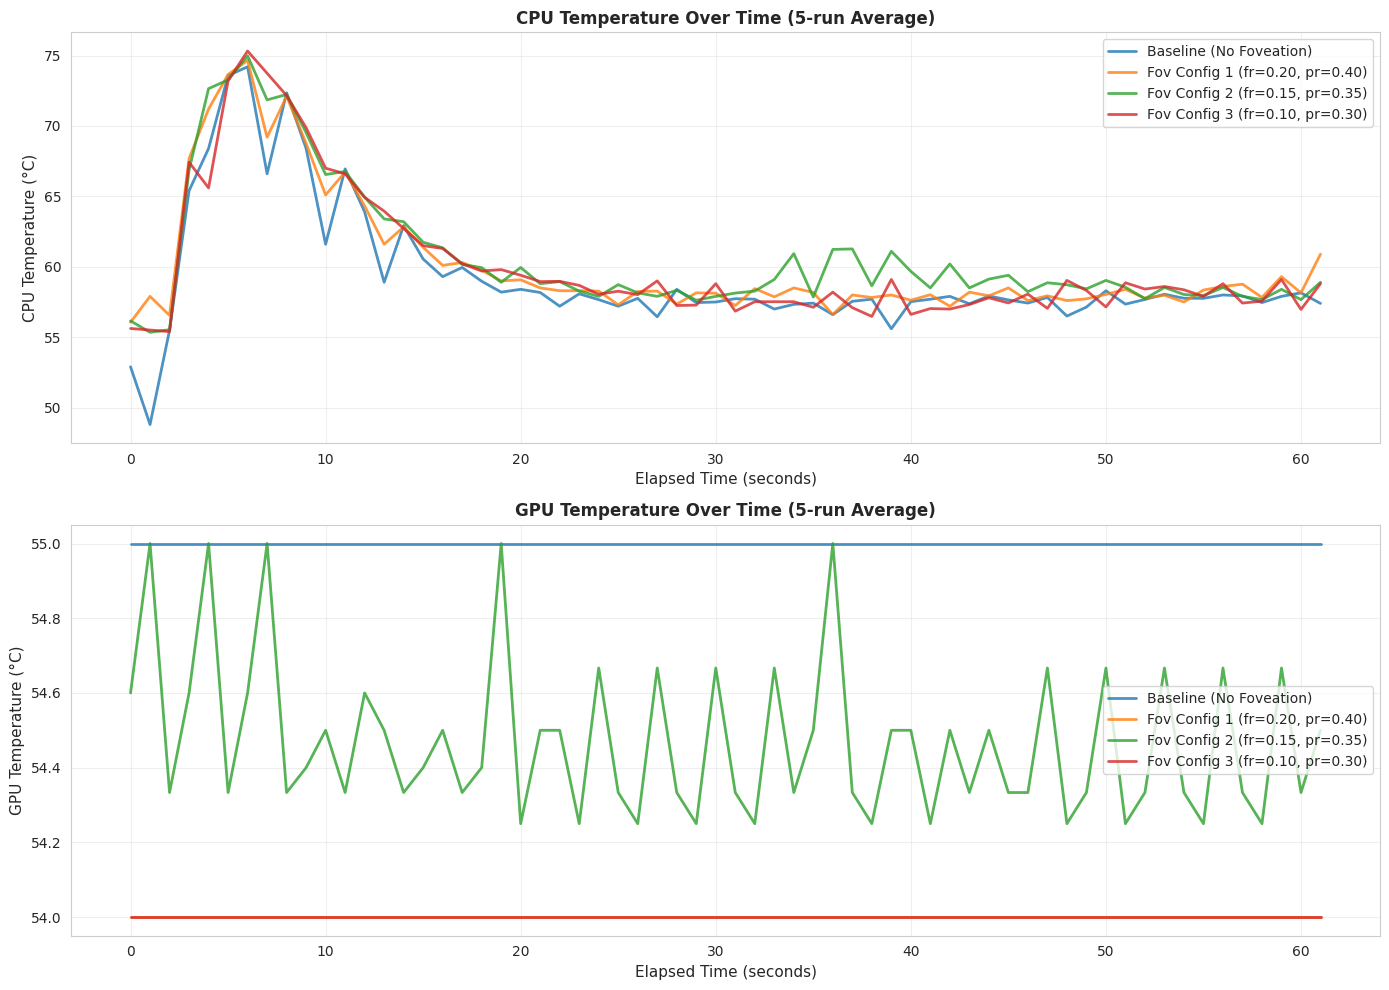

In [146]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# CPU Temperature Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax1.plot(ts['elapsed_s'], ts['cpu_temp_c'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax1.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax1.set_ylabel('CPU Temperature (°C)', fontsize=11)
ax1.set_title('CPU Temperature Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# GPU Temperature Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax2.plot(ts['elapsed_s'], ts['gpu_temp_c'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax2.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax2.set_ylabel('GPU Temperature (°C)', fontsize=11)
ax2.set_title('GPU Temperature Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 4: Overall Performance Metrics Comparison (Bar Charts)

/tmp/ipykernel_3350624/1218617134.py:33: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(avg_gpu) * 1.2)


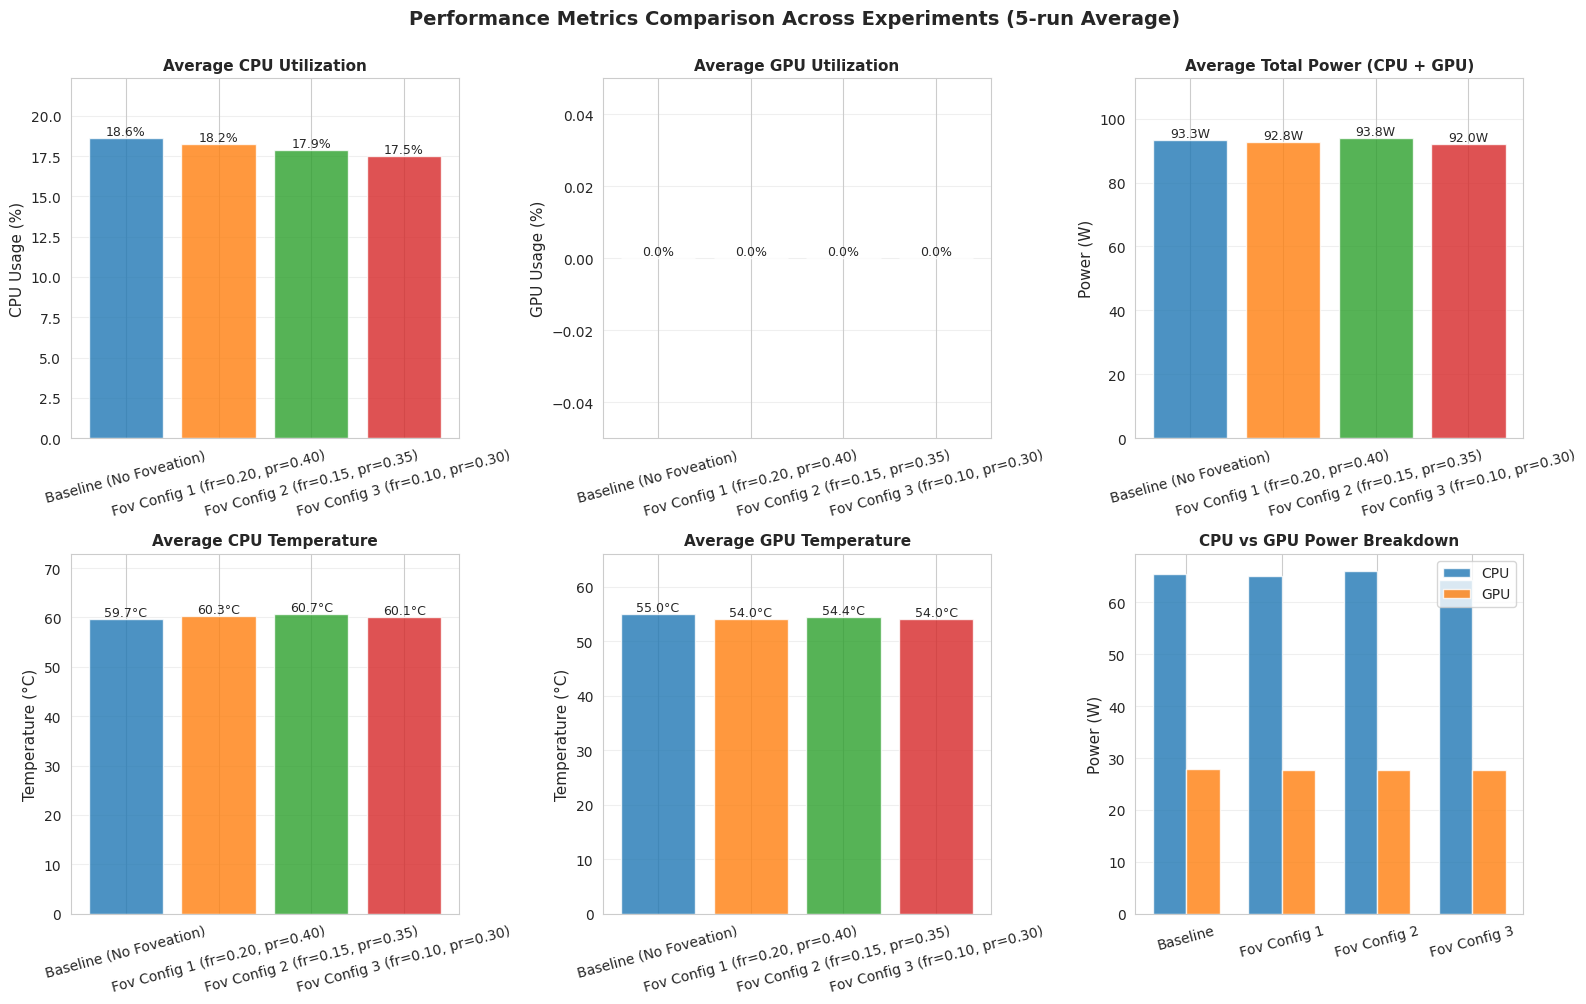

In [147]:
# Prepare comparison data
exp_names = list(averaged_data.keys())
display_names = [averaged_data[k]['display_name'] for k in exp_names]

avg_cpu = [averaged_data[e]['mean_metrics']['cpu_usr_pct'] + averaged_data[e]['mean_metrics']['cpu_sys_pct'] for e in exp_names]
avg_gpu = [averaged_data[e]['mean_metrics']['gpu_util_pct'] for e in exp_names]
avg_cpu_power = [averaged_data[e]['mean_metrics']['cpu_power_w'] for e in exp_names]
avg_gpu_power = [averaged_data[e]['mean_metrics']['gpu_power_w'] for e in exp_names]
avg_total_power = [p_cpu + p_gpu for p_cpu, p_gpu in zip(avg_cpu_power, avg_gpu_power)]
avg_cpu_temp = [averaged_data[e]['mean_metrics']['cpu_temp_c'] for e in exp_names]
avg_gpu_temp = [averaged_data[e]['mean_metrics']['gpu_temp_c'] for e in exp_names]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Performance Metrics Comparison Across Experiments (5-run Average)', fontsize=14, fontweight='bold', y=1.00)

# CPU Utilization
ax = axes[0, 0]
bars = ax.bar(display_names, avg_cpu, color=colors, alpha=0.8)
ax.set_ylabel('CPU Usage (%)', fontsize=11)
ax.set_title('Average CPU Utilization', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(avg_cpu) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# GPU Utilization
ax = axes[0, 1]
bars = ax.bar(display_names, avg_gpu, color=colors, alpha=0.8)
ax.set_ylabel('GPU Usage (%)', fontsize=11)
ax.set_title('Average GPU Utilization', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(avg_gpu) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# Total Power
ax = axes[0, 2]
bars = ax.bar(display_names, avg_total_power, color=colors, alpha=0.8)
ax.set_ylabel('Power (W)', fontsize=11)
ax.set_title('Average Total Power (CPU + GPU)', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(avg_total_power) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}W', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# CPU Temperature
ax = axes[1, 0]
bars = ax.bar(display_names, avg_cpu_temp, color=colors, alpha=0.8)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Average CPU Temperature', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(avg_cpu_temp) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}°C', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# GPU Temperature
ax = axes[1, 1]
bars = ax.bar(display_names, avg_gpu_temp, color=colors, alpha=0.8)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Average GPU Temperature', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(avg_gpu_temp) * 1.2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}°C', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# CPU Power breakdown
ax = axes[1, 2]
x_pos = np.arange(len(display_names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, avg_cpu_power, width, label='CPU', color='#1f77b4', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, avg_gpu_power, width, label='GPU', color='#ff7f0e', alpha=0.8)
ax.set_ylabel('Power (W)', fontsize=11)
ax.set_title('CPU vs GPU Power Breakdown', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([name.split('(')[0].strip() for name in display_names], rotation=15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [148]:
# Create summary table
summary_data = {
    'Configuration': display_names,
    'Avg CPU (%)': [f'{x:.2f}' for x in avg_cpu],
    'Avg GPU (%)': [f'{x:.2f}' for x in avg_gpu],
    'Avg CPU Power (W)': [f'{x:.2f}' for x in avg_cpu_power],
    'Avg GPU Power (W)': [f'{x:.2f}' for x in avg_gpu_power],
    'Total Power (W)': [f'{x:.2f}' for x in avg_total_power],
    'CPU Temp (°C)': [f'{x:.2f}' for x in avg_cpu_temp],
    'GPU Temp (°C)': [f'{x:.2f}' for x in avg_gpu_temp],
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY STATISTICS (5-Run Averages)")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


SUMMARY STATISTICS (5-Run Averages)
                  Configuration Avg CPU (%) Avg GPU (%) Avg CPU Power (W) Avg GPU Power (W) Total Power (W) CPU Temp (°C) GPU Temp (°C)
        Baseline (No Foveation)       18.60        0.00             65.47             27.84           93.31         59.65         55.00
Fov Config 1 (fr=0.20, pr=0.40)       18.24        0.00             65.14             27.68           92.82         60.29         54.00
Fov Config 2 (fr=0.15, pr=0.35)       17.89        0.00             66.07             27.78           93.85         60.72         54.45
Fov Config 3 (fr=0.10, pr=0.30)       17.50        0.00             64.25             27.70           91.95         60.09         54.00


## Visualization 5: Foveation Impact Analysis (% Change vs Baseline)

/tmp/ipykernel_3350624/3695268098.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pct_gpu_change = [(x - baseline_gpu) / baseline_gpu * 100 for x in avg_gpu]


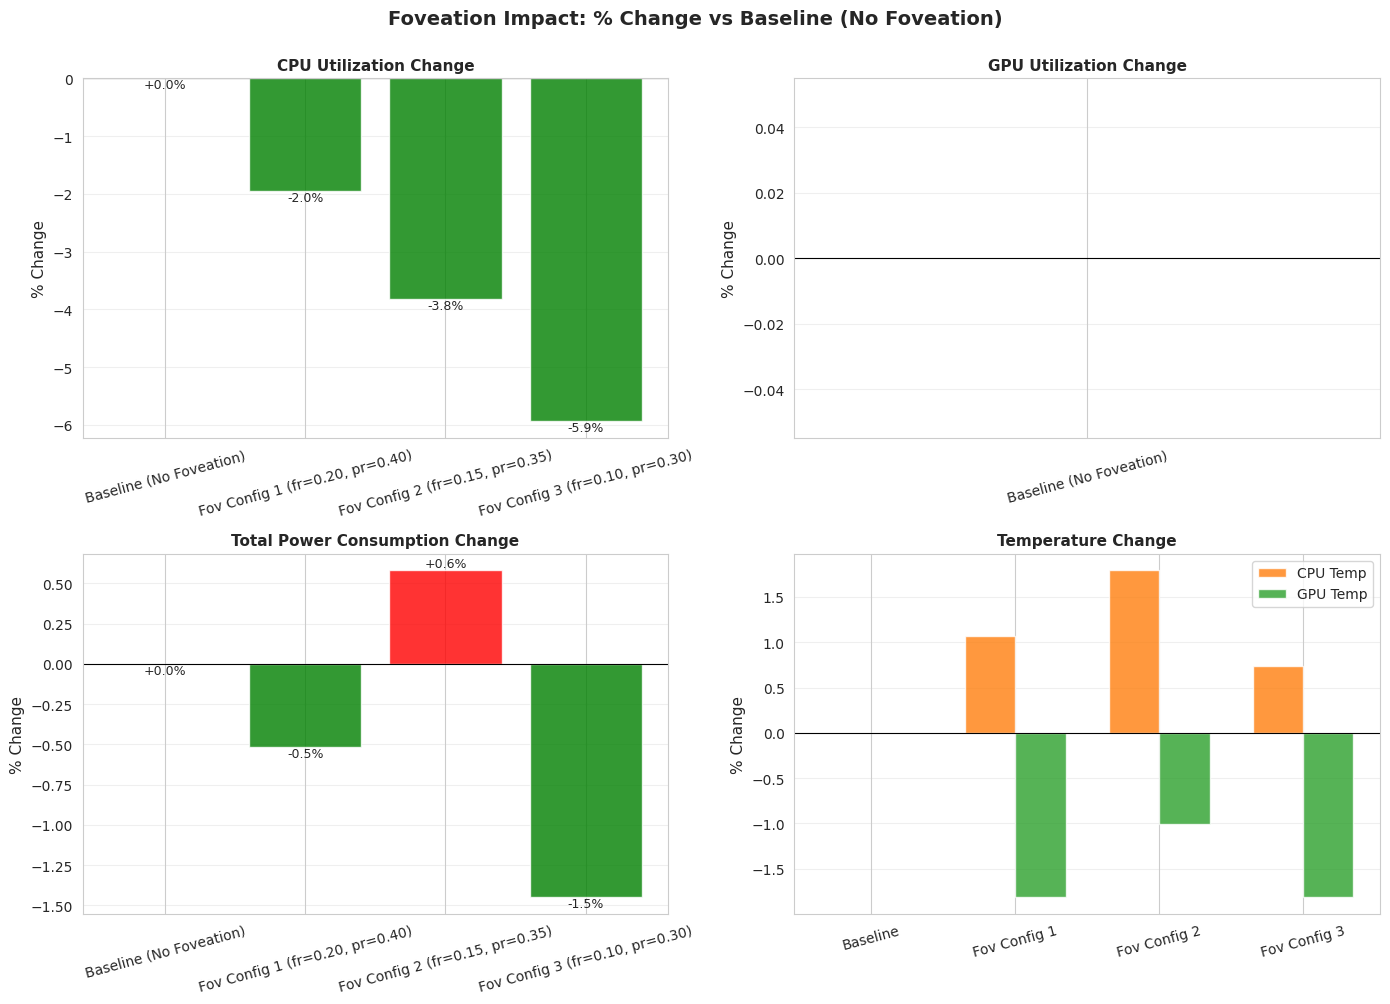

In [149]:
# Calculate percentage differences vs baseline_off
baseline_cpu = avg_cpu[0]
baseline_gpu = avg_gpu[0]
baseline_power = avg_total_power[0]
baseline_cpu_temp = avg_cpu_temp[0]
baseline_gpu_temp = avg_gpu_temp[0]

# Compute deltas
pct_cpu_change = [(x - baseline_cpu) / baseline_cpu * 100 for x in avg_cpu]
pct_gpu_change = [(x - baseline_gpu) / baseline_gpu * 100 for x in avg_gpu]
pct_power_change = [(x - baseline_power) / baseline_power * 100 for x in avg_total_power]
pct_cpu_temp_change = [(x - baseline_cpu_temp) / baseline_cpu_temp * 100 for x in avg_cpu_temp]
pct_gpu_temp_change = [(x - baseline_gpu_temp) / baseline_gpu_temp * 100 for x in avg_gpu_temp]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Foveation Impact: % Change vs Baseline (No Foveation)', fontsize=14, fontweight='bold', y=1.00)

# CPU Utilization Change
ax = axes[0, 0]
bars = ax.bar(display_names, pct_cpu_change, color=['green' if x < 0 else 'red' for x in pct_cpu_change], alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('% Change', fontsize=11)
ax.set_title('CPU Utilization Change', fontsize=11, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# GPU Utilization Change
ax = axes[0, 1]
bars = ax.bar(display_names, pct_gpu_change, color=['green' if x < 0 else 'red' for x in pct_gpu_change], alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('% Change', fontsize=11)
ax.set_title('GPU Utilization Change', fontsize=11, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# Total Power Change
ax = axes[1, 0]
bars = ax.bar(display_names, pct_power_change, color=['green' if x < 0 else 'red' for x in pct_power_change], alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('% Change', fontsize=11)
ax.set_title('Total Power Consumption Change', fontsize=11, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# Temperature Change
ax = axes[1, 1]
x_pos = np.arange(len(display_names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, pct_cpu_temp_change, width, label='CPU Temp', alpha=0.8, color='#ff7f0e')
bars2 = ax.bar(x_pos + width/2, pct_gpu_temp_change, width, label='GPU Temp', alpha=0.8, color='#2ca02c')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('% Change', fontsize=11)
ax.set_title('Temperature Change', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([name.split('(')[0].strip() for name in display_names], rotation=15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Visualization 6: Memory Usage Over Time

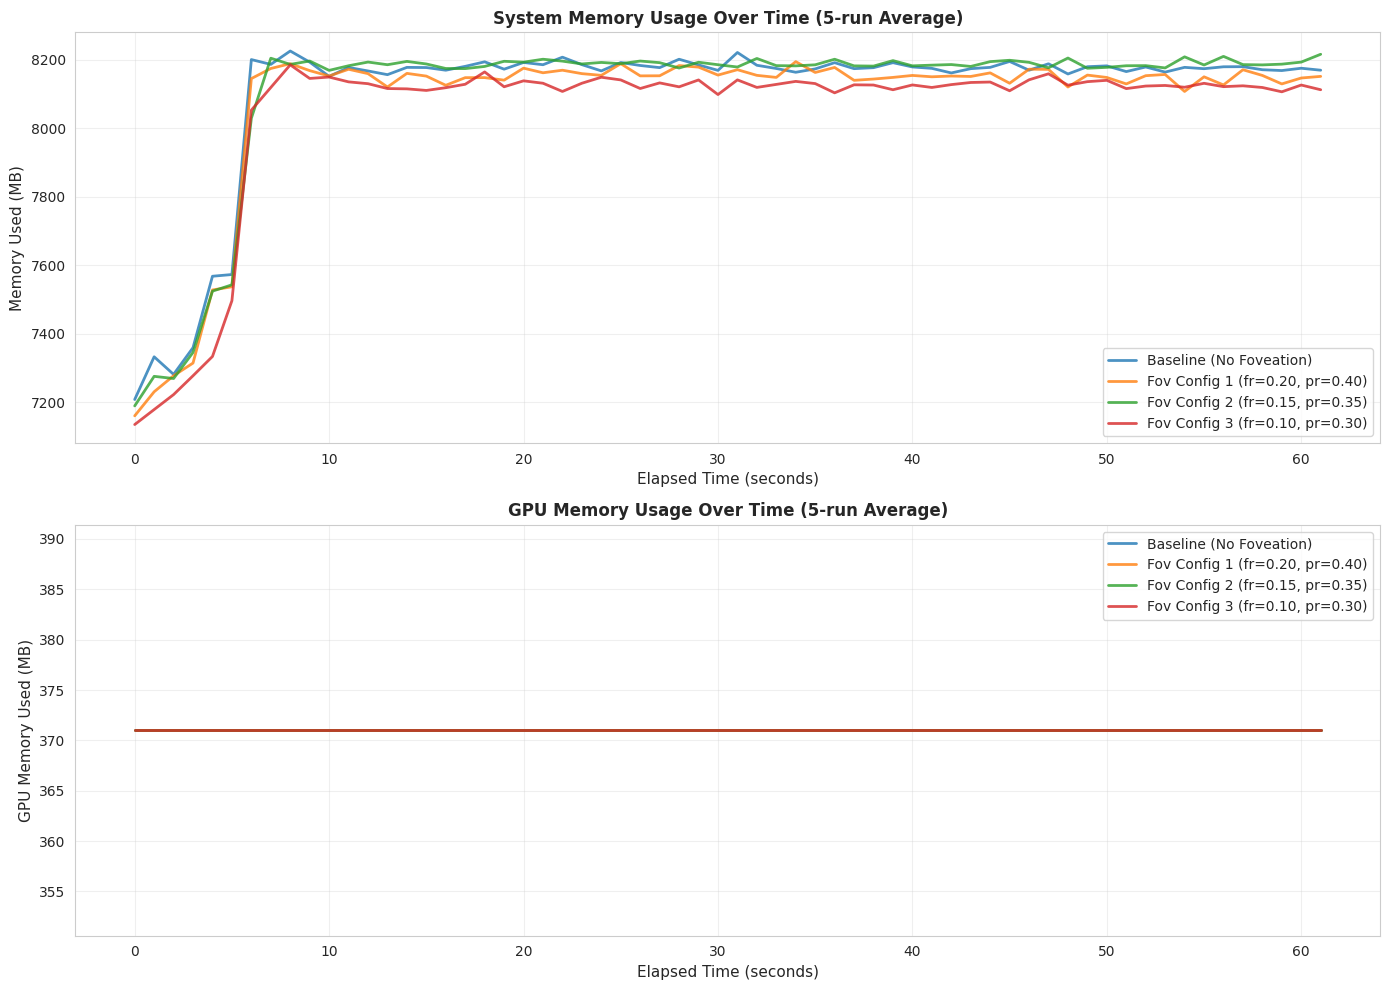

In [150]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# System Memory Used Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax1.plot(ts['elapsed_s'], ts['mem_used_mb'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax1.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax1.set_ylabel('Memory Used (MB)', fontsize=11)
ax1.set_title('System Memory Usage Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# GPU Memory Used Over Time
for idx, (exp_name, exp_info) in enumerate(averaged_data.items()):
    ts = exp_info['time_series']
    ax2.plot(ts['elapsed_s'], ts['gpu_mem_used_mb'], label=exp_info['display_name'], 
             linewidth=2, color=colors[idx], alpha=0.8)

ax2.set_xlabel('Elapsed Time (seconds)', fontsize=11)
ax2.set_ylabel('GPU Memory Used (MB)', fontsize=11)
ax2.set_title('GPU Memory Usage Over Time (5-run Average)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()